# Unsupervised Learning

* Discovery pattern in unlabelled data.
* You only have input data and no corresponding output variables.

**Goal:**
* To model the underlying structure or distribution in the data in order to learn more about the data.

### How to do?

**Clustering**
* Group of similar data points
* Extract the structure of the data
* Identify groups in the data

eg: Purchasing behavior

**Association**
* rule-based approach
* discovering interesting relationships between features

eg: 
1) People that buy X tend to buy Y
2) People that buy A+B tend to buy C

**K-Means Clustering**
* A simple algorithm
* Way to compare observations
* To guess how many clusters
* To calculate average for each cluster


**Applications**
* Anomaly detection
* Customer segmentation
* Recommendation Engines

### K-Means Clustering
* Find the best centroids
* Randomly assign centroids
* Selecting mean data points
* We need to know how many data
* Optimize the centroids


**Coding Exercise**

In [158]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Generate sample data
X = np.random.rand(100, 2)

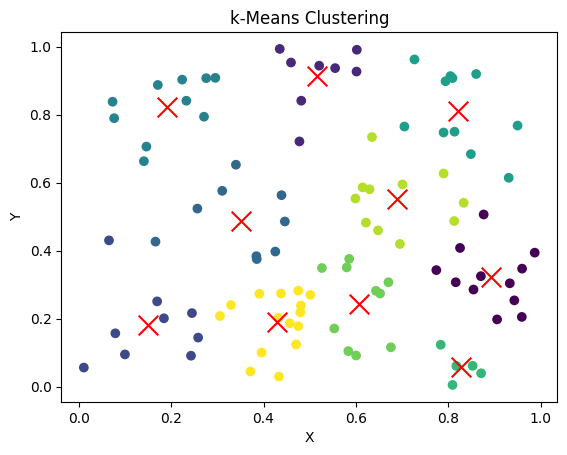

In [159]:
# Initialize the k-means algorithm with the desired number of clusters (k)
k = 10
kmeans = KMeans(n_clusters=k,algorithm='elkan') 

# Fit the data to the k-means algorithm
kmeans.fit(X)

# Retrieve the cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plot the data points and cluster centroids
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200, c='red')
plt.title('k-Means Clustering')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [160]:
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Generate sample data
X = np.random.rand(500, 2)
k = 5  # number of clusters

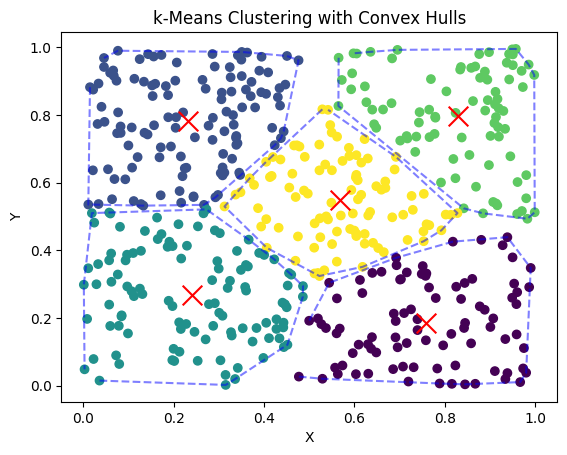

In [161]:
# Fit the data to the k-means algorithm
kmeans = KMeans(n_clusters=k)
kmeans.fit(X)

# Retrieve the cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plot the data points and cluster centroids
plt.scatter(X[:, 0], X[:, 1], c=labels,cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200, c='red')

# Loop through each cluster and draw convex hull around it
for cluster in range(k):
  # Get data points belonging to the current cluster
  data_points = X[labels == cluster]
  # Create convex hull object
  hull = ConvexHull(data_points)
  # Extract vertices of the convex hull
  vertices = data_points[hull.vertices]
  # Plot the hull as a closed loop
  plt.plot(vertices[:, 0], vertices[:, 1], 'b--', alpha=0.5)

plt.title('k-Means Clustering with Convex Hulls')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Hyper parameter Fine-tuning
**Elbow method** 


In [162]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [163]:
df = pd.read_csv('../../dataset/Iris.csv')
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [164]:
x=df[['SepalLengthCm', 'SepalWidthCm','PetalLengthCm', 'PetalWidthCm']]
x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [165]:
def determine_optimal_clusters(X_scaled, max_clusters=3):
    distances = []

    for n in range(2, max_clusters+1):
        kmeans = KMeans(n_clusters=n, random_state=42)
        kmeans.fit(X_scaled)
        distances.append(kmeans.inertia_)

    plt.figure(figsize=(7, 5))
    plt.plot(range(2, max_clusters+1), distances, marker='o')
    plt.title('Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('Sum of squared distances')
    plt.xticks(range(2, max_clusters+1))
    plt.grid(True)
    plt.show()

    return distances


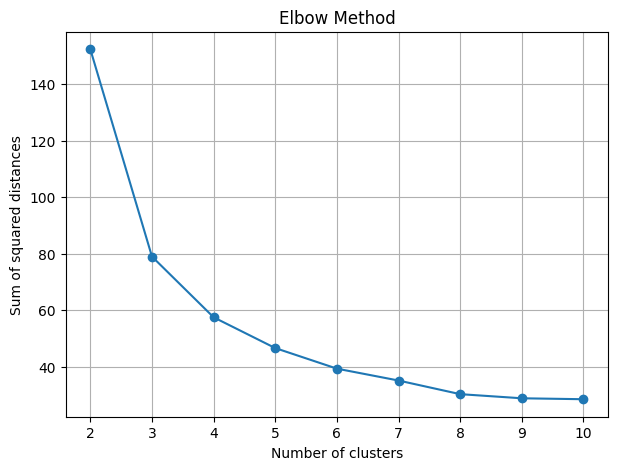

In [170]:
from sklearn.preprocessing import MinMaxScaler
max_cluster = 10
# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(x)
distances = determine_optimal_clusters(x,max_cluster)

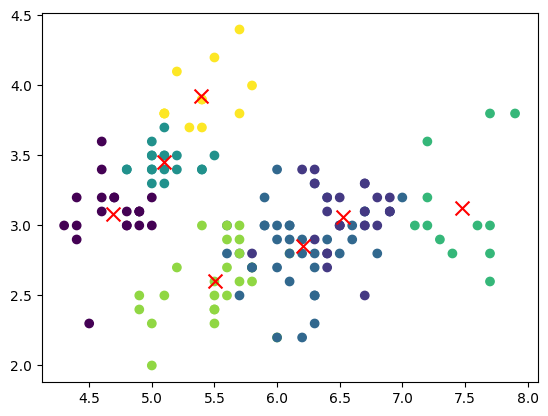

In [177]:
from scipy.spatial import ConvexHull
# Fit the data to the k-means algorithm
kmeans = KMeans(n_clusters=7)
kmeans.fit(x)

# Retrieve the cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plot the data points and cluster centroids
plt.scatter(df['SepalLengthCm'],df['SepalWidthCm'], c=labels,cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=100, c='red')


plt.show()

### Density-based spatial clustering of application noise (DBSCAN)
* requires 2 parameter = Epsilon and minPoints
* Epsilon = radius
* minPoints = minimum number of data points

 **Coding Exercise**

In [308]:
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate sample data
X = np.random.randn(100, 2)

# Instantiate DBSCAN object
dbscan = DBSCAN(eps=0.3, min_samples=5)

# Fit the data
dbscan.fit(X)

# Get cluster labels and core sample indices
labels = dbscan.labels_
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Number of clusters in labels, ignoring noise if present
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# Print the results
print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)


Estimated number of clusters: 3
Estimated number of noise points: 63


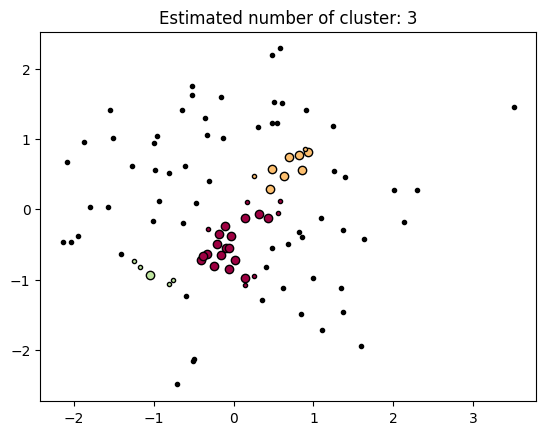

In [309]:
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0,1,len(unique_labels))]

for k, col in zip(unique_labels,colors):
    if k==-1:
        col = [0,0,0,1]

    class_member_mask=(labels==k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:,0],xy[:,1],'o',markerfacecolor=tuple(col),markeredgecolor='k', markersize=6)
    
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:,0],xy[:,1],'o',markerfacecolor=tuple(col),markeredgecolor='k', markersize=3)

    plt.title('Estimated number of cluster: %d' % n_clusters_)
    plt.show

### Outliers Detection
* **Isolation Forest**
    * Recursive random partitioning
    * To isolate outliers from inliers

In [310]:
#Create sample and outliers

import numpy as np
from sklearn.model_selection import train_test_split

n_samples, n_outliers = 120, 40
rng = np.random.RandomState(0)

covariance = np.array([[0.5, -0.1], [0.7, 0.4]])
cluster_1 = 0.4 * rng.randn(n_samples, 2) @ covariance + np.array([2, 2])  # general
cluster_2 = 0.3 * rng.randn(n_samples, 2) + np.array([-2, -2])  # spherical
outliers = rng.uniform(low=-4, high=4, size=(n_outliers, 2))

X = np.concatenate([cluster_1, cluster_2, outliers])

y = np.concatenate([np.ones((2 * n_samples), dtype=int), -np.ones((n_outliers), dtype=int)])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)


<function matplotlib.pyplot.show(close=None, block=None)>

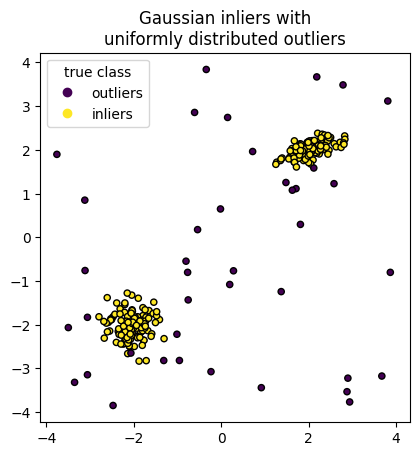

In [312]:
import matplotlib.pyplot as plt

scatter = plt.scatter(X[:,0],X[:,1], c=y, s=20, edgecolor='k')
handles,labels = scatter.legend_elements()
plt.axis("square")
plt.legend(handles=handles, labels=['outliers','inliers'], title="true class")
plt.title("Gaussian inliers with\nuniformly distributed outliers")
plt.show

**Trainin of the model**

In [315]:
from sklearn.ensemble import IsolationForest

clf=IsolationForest(max_samples=100,random_state=0)
clf.fit(X_train)

IsolationForest(max_samples=100, random_state=0)

**Plot discrete decision boundary**

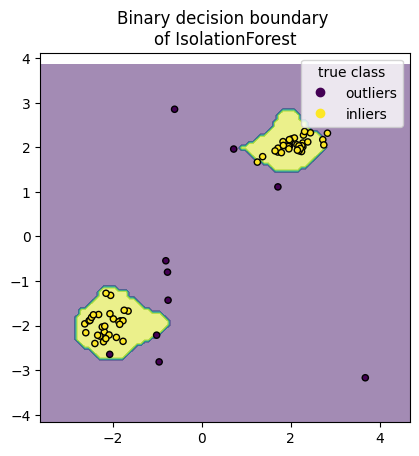

In [318]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test,
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20, edgecolor="k")
disp.ax_.set_title("Binary decision boundary \nof IsolationForest")
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.show()


**Plot path length decision boundary**

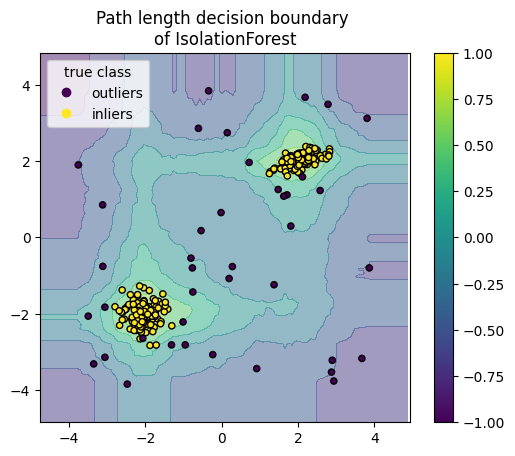

In [319]:
disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function",
    alpha=0.5,
)

disp.ax_.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
disp.ax_.set_title("Path length decision boundary \nof IsolationForest")
plt.axis("square")

plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.colorbar(disp.ax_.collections[1])

plt.show()


#### Dimensionality Reduction
1) Reduce dimension
2) Reduce computational power
3) Find principle component
4) De-noise model
5) Makes it easier and faster for the algorithm to analyze the data

**Techniques:-**
* Drop data columns with issing values
* Drop data columns with low variance
* Drop data columns with hight correlations
* Apply statistical functions - PCA

#### Principal Component Analysis (PCA)
It is a linear dimensionality reduction method
- To compress or reduce the data
- Capture the variance
- Reduce dimensionality and build feature vector

Explained variance ratio: [0.92461872 0.05306648]


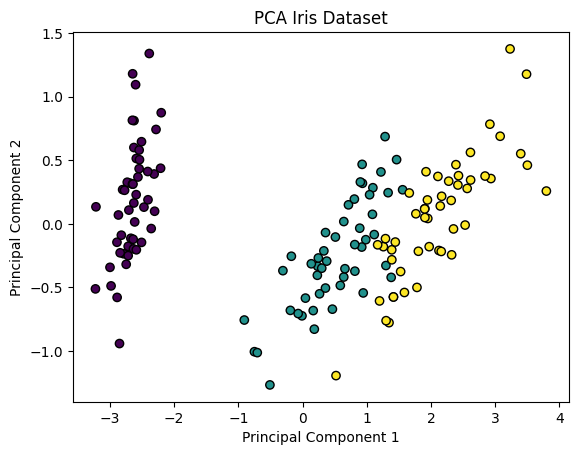

In [322]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Instantiate PCA object
pca = PCA(n_components=2) #n_component -> reduce it to 2

# Perform PCA
X_pca = pca.fit_transform(X)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_ #Know the variance

# Print the explained variance ratio
print('Explained variance ratio:', explained_variance_ratio)

# Plot the data in the new feature space
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('PCA Iris Dataset')
plt.show()


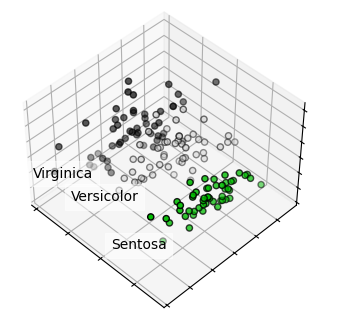

In [331]:
from sklearn import datasets, decomposition
# Load the Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

fig = plt.figure(1,figsize=(4,3))
plt.clf() #clear all the current figure but let the window opened

ax = fig.add_subplot(111,projection="3d", elev=45, azim=135)
ax.set_position([0,0,0.95,1])

plt.cla() #clear all the  current axes
pca=decomposition.PCA(n_components=3)
pca.fit(X)
X=pca.transform(X)

for name,label in [("Sentosa",0),("Versicolor",1),("Virginica",2)]:
    ax.text3D(
        X[y== label,0].mean(),
        X[y== label,1].mean()+1.5,
        X[y== label,2].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.5, edgecolor="w", facecolor="w"),
    )

# Reorder the labels to have colors matching the cluster results
y = np.choose(y,[1,2,0]).astype(float)
ax.scatter(X[:,0],X[:,1],X[:,2],c=y,cmap=plt.cm.nipy_spectral, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

plt.show()

#### Comparison of LDA and PCA 2D projection of Iris Dataset

explained variance ration (first two components):[0.92461872 0.05306648]


c:\Users\Muhammad Afiq\anaconda3\envs\python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


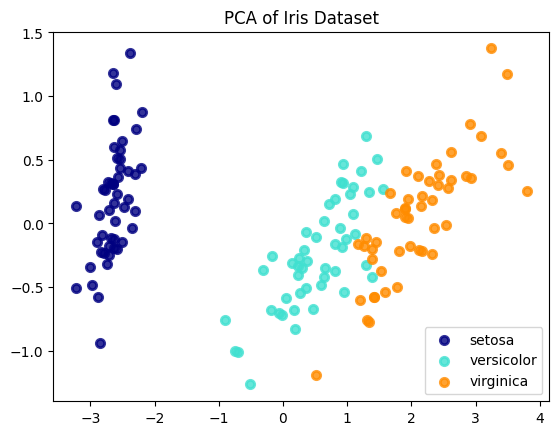

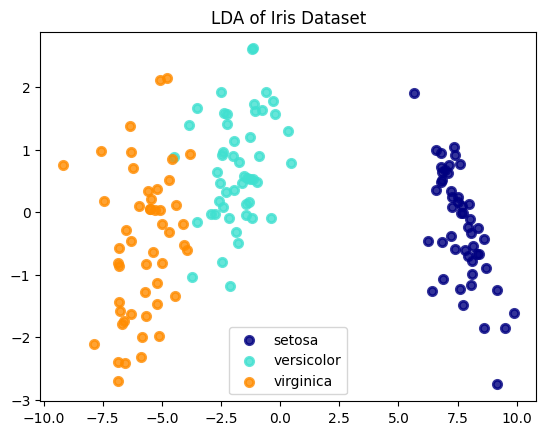

In [334]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load the Iris dataset
iris = load_iris()

X = iris.data
y = iris.target
target_names = iris.target_names

# Instantiate PCA object
pca = PCA(n_components=2) #n_component -> reduce it to 2

# Perform PCA
X_r = pca.fit_transform(X)

lda = LinearDiscriminantAnalysis(n_components=2)
X_r2 = lda.fit(x,y).transform(X)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_ #Know the variance

#Percentatge of variance explained for each components
print(
    "explained variance ration (first two components):%s"
    % str(pca.explained_variance_ratio_))

plt.figure()
colors = ["navy","turquoise","darkorange"]
lw=2

for color, i, target_name in zip(colors,[0,1,2], target_names):
    plt.scatter(
        X_r[y==i,0],X_r[y==i,1], color=color, alpha=0.8, lw=lw, label=target_name
    )

plt.legend(loc="best",shadow=False, scatterpoints=1)
plt.title("PCA of Iris Dataset")

plt.figure()
for color, i, target_name in zip(colors,[0,1,2], target_names):
    plt.scatter(
        X_r2[y==i,0],X_r2[y==i,1], color=color, alpha=0.8, lw=lw, label=target_name
    )

plt.legend(loc="best",shadow=False, scatterpoints=1)
plt.title("LDA of Iris Dataset")

plt.show()